In [1]:
#julia -t 4

using Plots
using Random, Statistics, Distributions
using SparseArrays
using LinearAlgebra
using DifferentialEquations
using StatsPlots 

using Statistics 
using Distributions, Random, Plots, StatsBase  
using Base.Threads



include("../Project_with_Jon/GPs.jl")
include("../Project_with_Jon/functions.jl")
include("../Project_with_Jon/myfuncs.jl")
include("../Project_with_Jon/integrators.jl")
include("../Project_with_Jon/util_shoji.jl")


simulate_pf_selforg (generic function with 1 method)

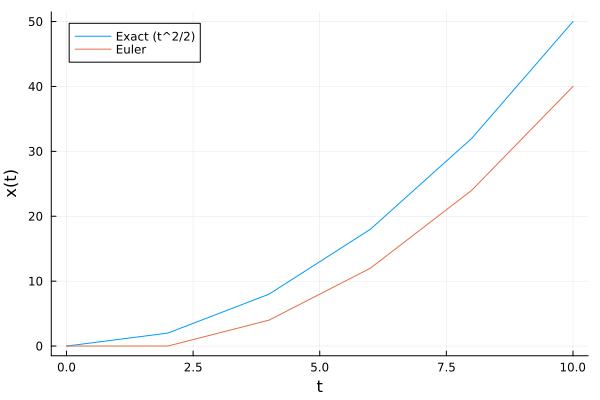

In [2]:
u0 = 0.0
dt = 2.0
T = 10
tspan = 0:dt:T

function reaction(u, p, t)
    return t
end

sol = exact(reaction, u0, tspan, Tsit5(), 1e-10, 1e-10)

numsol, _ = numerical_integration(
    reaction,
    Euler,
    u0,
    dt,
    length(tspan),
    1
)

plot(tspan, sol,
    label="Exact (t^2/2)",
    xlabel="t",
    ylabel="x(t)"
)

plot!(tspan, numsol,
    label="Euler"
)



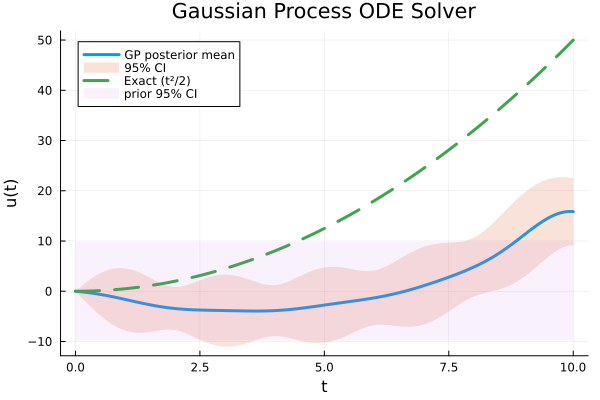

y:[0.0, 0.0, 2.0, 4.0, 6.0, 8.0]


In [16]:
using LinearAlgebra
using Plots



# =====================================================
# Cov(L_i,L_j)
#
# L_i u =
# (u(t_i+dt)-u(t_i))/dt
# =====================================================

function K_LL(ts; dt, ℓ=1.0, σf=1.0)

    n = length(ts)

    K = zeros(n,n)

    for i in 1:n
        for j in 1:n

            ti = ts[i]
            tj = ts[j]

            K[i,j] =
                (
                    rbf_kernel(ti+dt,tj+dt; ℓ=ℓ, σf=σf)
                    -
                    rbf_kernel(ti+dt,tj; ℓ=ℓ, σf=σf)
                    -
                    rbf_kernel(ti,tj+dt; ℓ=ℓ, σf=σf)
                    +
                    rbf_kernel(ti,tj; ℓ=ℓ, σf=σf)
                ) / dt^2

        end
    end

    K
end

# =====================================================
# Observation covariance
#
# observations:
#
# [u(0),
#  L0u,
#  L1u,
#  ...]
# =====================================================

function build_observation_covariance(ts;
                                      dt,
                                      ℓ,
                                      σf)

    n = length(ts)

    K = zeros(n+1,n+1)

    #
    # Cov(u(0),u(0))
    #

    K[1,1] =
        rbf_kernel(
            0.0,
            0.0;
            ℓ=ℓ,
            σf=σf
        )

    #
    # Cov(u(0),Lj)
    #

    for j in 1:n

        tj = ts[j]

        K[1,j+1] =
            (
                rbf_kernel(
                    0.0,
                    tj+dt;
                    ℓ=ℓ,
                    σf=σf
                )
                -
                rbf_kernel(
                    0.0,
                    tj;
                    ℓ=ℓ,
                    σf=σf
                )
            ) / dt

        K[j+1,1] =
            K[1,j+1]

    end

    #
    # Cov(Li,Lj)
    #

    K[2:end,2:end] .=
        K_LL(
            ts;
            dt=dt,
            ℓ=ℓ,
            σf=σf
        )

    K
end

# =====================================================
# Cov(u(t),L_j)
# =====================================================

function K_starL(X_test,
                 ts;
                 dt,
                 ℓ=1.0,
                 σf=1.0)

    m = length(X_test)
    n = length(ts)

    K = zeros(m,n)

    for i in 1:m
        for j in 1:n

            t = X_test[i]
            tj = ts[j]

            K[i,j] =
                (
                    rbf_kernel(t,tj+dt; ℓ=ℓ, σf=σf)
                    -
                    rbf_kernel(t,tj; ℓ=ℓ, σf=σf)
                ) / dt

        end
    end

    K
end



# =====================================================
# Cross covariance
#
# Cov(u(t), observations)
# =====================================================

function build_cross_covariance(X_test,
                                ts;
                                dt,
                                ℓ,
                                σf)

    m = length(X_test)
    n = length(ts)

    K = zeros(m,n+1)

    #
    # Cov(u(t),u(0))
    #

    for i in 1:m

        K[i,1] =
            rbf_kernel(
                X_test[i],
                0.0;
                ℓ=ℓ,
                σf=σf
            )

    end

    #
    # Cov(u(t),Lj)
    #

    K[:,2:end] .=
        K_starL(
            X_test,
            ts;
            dt=dt,
            ℓ=ℓ,
            σf=σf
        )

    K
end

# =====================================================
# ODE
#
# u'(t)=t
#
# exact:
# u(t)=t²/2
# =====================================================

dt = 2.0

t_obs =
    collect(0:dt:8)

rhs =
    collect(t_obs)

#
# observations:
#
# u(0)=0
#
# (u(t_i+dt)-u(t_i))/dt = t_i
#

y =
    vcat(
        [0.0],
        rhs
    )

println("y:", y)

# =====================================================
# GP hyperparameters
# =====================================================

ℓ = 1.0
σf = 5.0

# =====================================================
# Posterior
# =====================================================

X_test =
    collect(
        range(
            0,
            10,
            length=500
        )
    )

K =
    build_observation_covariance(
        t_obs;
        dt=dt,
        ℓ=ℓ,
        σf=σf
    )

#K += 1e-10I


#Observation Noise
K[2:end,2:end] += 2 .* I

Ks =
    build_cross_covariance(
        X_test,
        t_obs;
        dt=dt,
        ℓ=ℓ,
        σf=σf
    )

Kss =
    kernel_matrix(
        X_test,
        X_test;
        ℓ=ℓ,
        σf=σf
    )

μ =
    Ks * (K \ y)

Σ =
    Kss -
    Ks * (K \ Ks')

std =
    sqrt.(max.(diag(Σ),0))

# =====================================================
# Exact solution
# =====================================================

u_exact(t) =
    t^2 / 2


# =====================================================
# Plot
# =====================================================

plot(
    X_test,
    μ,
    lw=3,
    label="GP posterior mean"
)

plot!(
    X_test,
    μ .+ 1.96 .* std,
    fillrange=
        μ .- 1.96 .* std,
    fillalpha=0.2,
    linealpha=0,
    label="95% CI"
)

plot!(
    X_test,
    u_exact.(X_test),
    lw=3,
    ls=:dash,
    label="Exact (t²/2)"
)

μ_prior = zeros(length(X_test))

Kss = kernel_matrix(
    X_test,
    X_test;
    ℓ=ℓ,
    σf=σf
)

std_prior = sqrt.(diag(Kss))


plot!(
    X_test,
    1.96 .* std_prior,
    fillrange = -1.96 .* std_prior,
    fillalpha=0.1,
    linealpha=0,
    label="prior 95% CI"
)

xlabel!("t")
ylabel!("u(t)")
title!("Gaussian Process ODE Solver")

display(current())

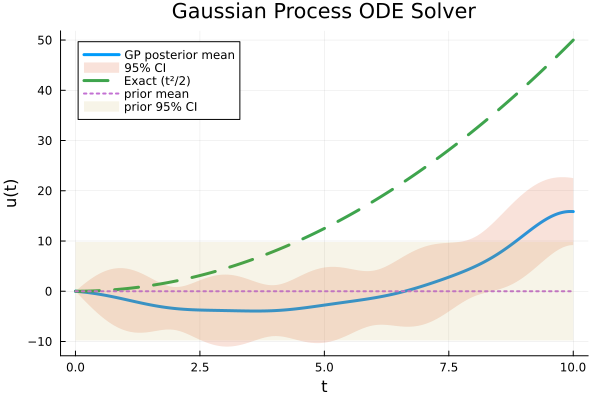

In [15]:
μ_prior = zeros(length(X_test))

Kss = kernel_matrix(
    X_test,
    X_test;
    ℓ=ℓ,
    σf=σf
)

std_prior = sqrt.(diag(Kss))

plot!(
    X_test,
    μ_prior,
    lw=2,
    label="prior mean",
    ls=:dot
)

plot!(
    X_test,
    1.96 .* std_prior,
    fillrange = -1.96 .* std_prior,
    fillalpha=0.1,
    linealpha=0,
    label="prior 95% CI"
)